In [177]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:100% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<font size="5" color="red"><b>ch4. 머신러닝 모형 최적화</b></font>
# 1절. 변수 선택과 차원 축소
## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임<br><br>
(어떻게 하면 score를 높일 수 있을지?)
- 과적합과 변수들 사이의 다중공선성(변수들간 강한 상관관계)을 줄일 수 있음 
    * 회귀계수 해석이 어려워짐.<br>
    모델 예측력이 좋아도 해석력이 떨어짐(어떤 변수가 제일 큰 요인인지 잘),<br>p값이나 유의성 검정이 왜곡될 수 있음<br>
- 모형의 학습 시간을 줄일 수 있음
- 주성분분석, 상관분석, <strong style='color:red;'>분류모형의 feature_importance_, 예측 모형의 coef_</strong>
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택

## 1-2 주성분분석(PCA, Principal Component Anaysis)
- 주성분분석은 변수 선택 및 차원축소 방법(기존의 모든 변수를 조합하여 새로운 변수로 만듦) 으로 널리 사용
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 <strong style='color:red;'>분산이 극대화된 상관관계가 없는 새로운 변수(주성분)들로 축약</strong>하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 <br><br>영상인식, 통계 데이터분석(주성분 찾기), 데이터 압축, 노이즈제거 등 여러 분야에 사용-영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [10]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:,:-1], iris.species
iris_X.head(2)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [11]:
pca = PCA(n_components=2) #n_compoenets=2 : 주성분의 갯수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:5]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451]])

In [12]:
# 각 주성분의 계수 : 각 주성분이 원래 특성들과 어떤 관계가 있는지 나타내는 가중치
pca.components_
# 주성분1 = 0.36138659*sl +(-0.08452251*sw) + (0.85667061*pl) + (0.3582892 *pw) : 회귀분석에 더 잘 맞음

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [13]:
# 설명분산 : 각 주성분 벡터가 정보량을 얼마나 잘 표현하는지(설명하는지)
pca.explained_variance_

array([4.22824171, 0.24267075])

In [14]:
# 설명분산을 0~1사이의 비율로 조정된 설명정도 : 주성분 결과 특성은 97.76852%만 반영이 됨.
pca.explained_variance_ratio_
# 첫번째 변수 : 92% 설명 / 두번째 변수 : 5% 설명 => 첫번째 + 두번째 는 100%가 안됨(97%) => acc 낮아짐


array([0.92461872, 0.05306648])

## 1-3 상관관계 확인 
- 각 변수들끼리의 상관관계 확인(시각화), 종속변수와 상관관계가 높은 변수들만 선택

In [18]:
import pandas as pd
# redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1030,7.1,0.59,0.0,2.1,0.091,9.0,14.0,0.99488,3.42,0.55,11.5,7


In [20]:
# 환경분석 
corr = redwine.corr()
# 상관관계 결과를 시각화 (heatmap)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [30]:
import numpy as np
import matplotlib.pyplot as plt

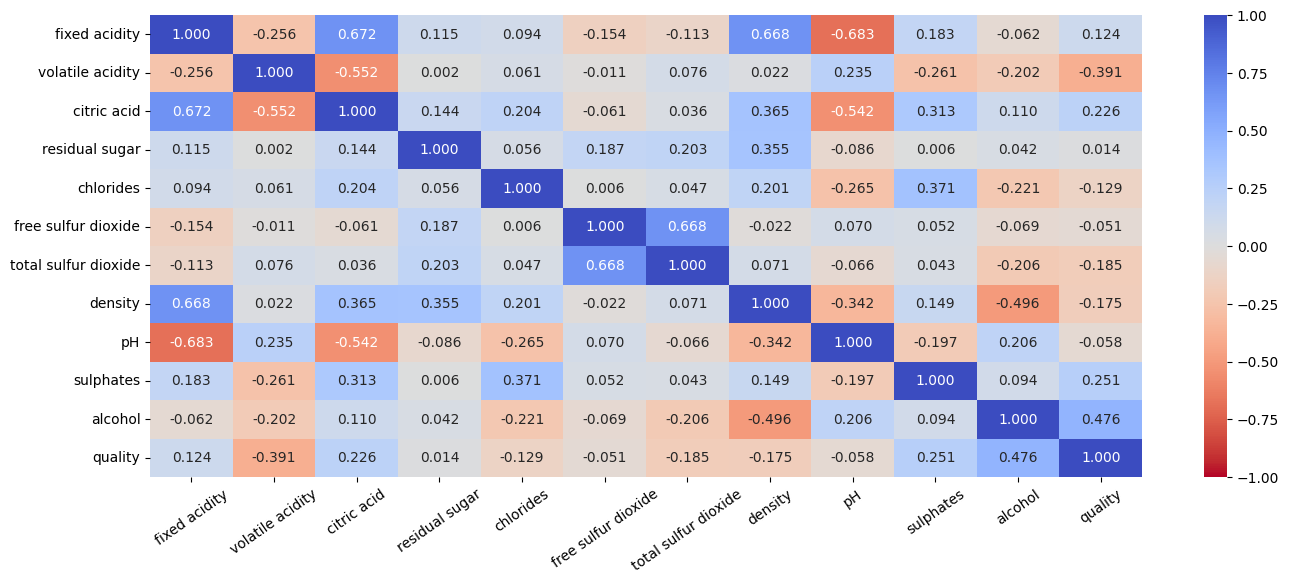

In [34]:
plt.figure(figsize=(16,6))
sns.heatmap(corr, annot=True,fmt='.3f', vmin=-1,vmax=1, cmap='coolwarm_r' )
plt.xticks(rotation=35)
plt.show()

In [43]:
np.triu(np.ones_like(corr), k=0) # 대각선 포함 위가 1인 삼각행렬 
np.triu(np.ones_like(corr), k=1) # 대각선 제외 위가 1인 삼각행렬 
np.tril(np.ones_like(corr), k=0) # 대각선 포함 아래가 1인 삼각행렬 
np.tril(np.ones_like(corr), k=-1) # 대각선 제외 아래가 1인 삼각행렬
# np.tril(np.ones_like(corr, dtype=bool), k=-1) # 대각선 제외 아래가 1인 삼각행렬 

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.]])

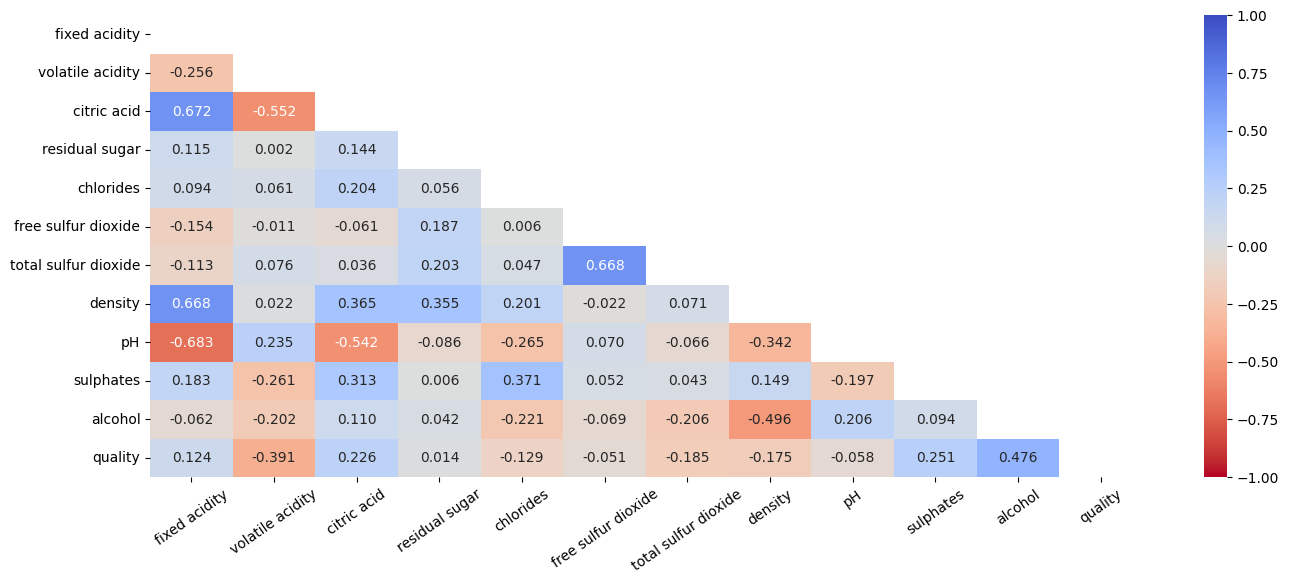

In [44]:
plt.figure(figsize=(16,6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True,fmt='.3f', vmin=-1,vmax=1, cmap='coolwarm_r', mask=mask )
plt.xticks(rotation=35)
plt.show()

## 1-4 분류모형의 Feature_importance_
- 분류모형의 feature_importance_ 속성은 각 독립변수들이 종속변수에 영향을 주는 정도
- LogistickRegression이나 SVC, MLP, GaussianNB 등은 Feature_importance_가 없음
- 그 외 분류모형은 사용가능

In [48]:
from sklearn.model_selection import train_test_split
X = redwine.iloc[:,:-1]
y = redwine.iloc[:,-1]
train_X,test_X,train_y,test_y = train_test_split(X,y,
                                                 test_size=0.3)
train_X.shape,train_y.shape,test_X.shape,test_y.shape

((1119, 11), (1119,), (480, 11), (480,))

In [50]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10, random_state=10) # 트리(디시젼트리) 갯수 10개 
rf_model.fit(train_X,train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [51]:
rf_model.feature_importances_

array([0.07444651, 0.09823359, 0.06901906, 0.0682099 , 0.07928549,
       0.062391  , 0.11067077, 0.08124397, 0.07626162, 0.10760586,
       0.17263223])

In [55]:
features = pd.DataFrame(data = np.c_[X.columns,rf_model.feature_importances_],
                        columns=['feature','importance'])
features['importance'].sum()

0.9999999999999998

In [59]:
features.sort_values(by='importance', ascending=False, inplace=True)
features.reset_index(drop=True, inplace=True)
features.head()

,feature,importance
0,alcohol,0.172632
1,total sulfur dioxide,0.110671
2,sulphates,0.107606
3,volatile acidity,0.098234
4,density,0.081244


### feature_importance_를 이용한 변수 중요도 시각화 

<function matplotlib.pyplot.show(close=None, block=None)>

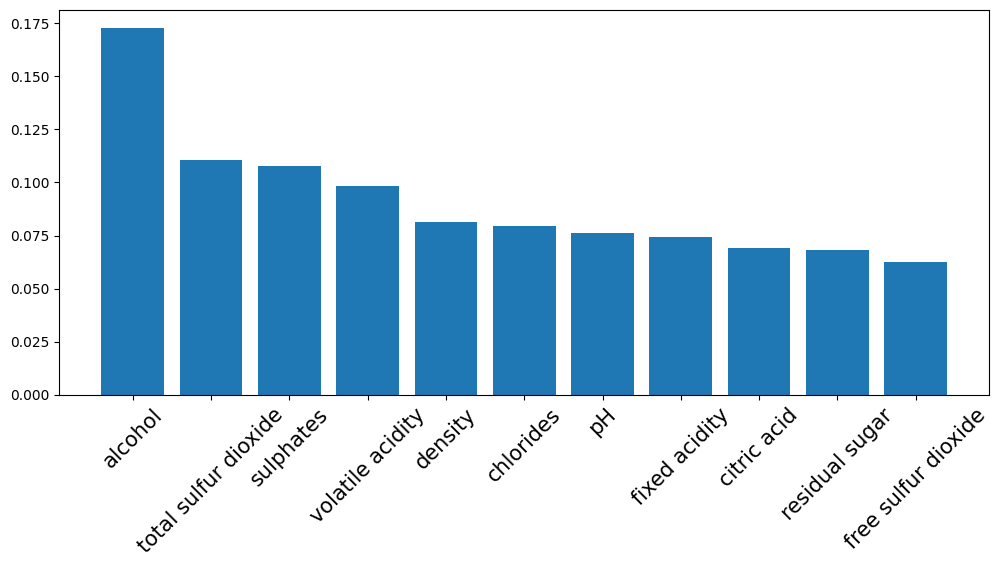

In [64]:
plt.figure(figsize=(12,5))
plt.bar(features.feature, features.importance)
plt.xticks(rotation=45, fontsize=15)
plt.show

In [68]:
# features.importance 누적합
# l = [1,2,3]
# np.cumsum(l)
y_stack = np.cumsum(features.importance)
np.c_[features.importance, y_stack]

array([[0.1726322307395159, 0.1726322307395159],
       [0.11067077380850239, 0.28330300454801827],
       [0.10760585781496249, 0.3909088623629807],
       [0.09823359198471605, 0.48914245434769676],
       [0.08124397085849294, 0.5703864252061897],
       [0.07928549292495227, 0.6496719181311419],
       [0.07626161749525764, 0.7259335356263995],
       [0.07444651032749301, 0.8003800459538926],
       [0.06901905948404821, 0.8693991054379407],
       [0.06820989740453619, 0.937609002842477],
       [0.06239099715752291, 0.9999999999999999]], dtype=object)

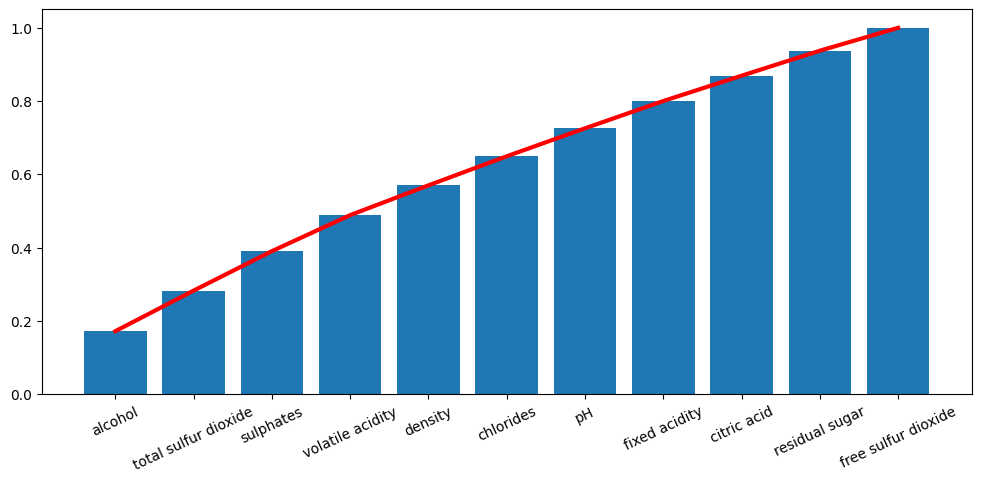

In [73]:
# 누적합을 이용하여 시각화
plt.figure(figsize=(12,5))
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, color='red', lw=3)
plt.xticks(rotation=25)
plt.show()

### RFE(Recursive Feature Elimination) 반식 
- RFE 클래스를 이용 : 중요도에 따라 중요도가 낮은 변수부터 하나씩 제거해 가면서 최종 선택된 변수 개수만큼 중요도가 높은 변수를 찾는다.

In [76]:
# 5개 특징이 남을때까지 변수를 제거(기준 : feature_importances_)
from sklearn.feature_selection import RFE
rfe = RFE(rf_model, n_features_to_select=5).fit(train_X,train_y)
rfe.get_support()

array([False,  True, False, False, False, False,  True,  True, False,
        True,  True])

In [79]:
features_rfe = pd.DataFrame(data = np.c_[X.columns,rfe.get_support()],
                            columns=['feature','selected'])
features_rfe[features_rfe.selected==True]

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True


## 1-5 SelectKBest
- 가장 높은 score에 따라 k개 feature 선택

In [81]:
from sklearn.feature_selection import SelectKBest, f_classif,chi2
X = iris.iloc[:,:-1].values
y = iris.iloc[:,-1].values
X.shape,y.shape, type(X),type(y)

((150, 4), (150,), numpy.ndarray, numpy.ndarray)

In [85]:
features_name = iris.columns[:-1].tolist()
features_name

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [87]:
# 가장 중요한 feature 1개 추출
# f_classif : y는 범주형. X는 연속형
# chi2 : y는 범주형. X는 범주형, 양의 실수일때 적합
# mutual_info : 비선형 데이터 고려 ...
X_new = SelectKBest(f_classif, # x가 연속형
                    k=1 # 추출될 feature 갯수
                   ).fit_transform(X,y)
X_new[:3] # petal_length 

array([[1.4],
       [1.4],
       [1.3]])

In [88]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 2절. 파라미터 선택 
- 하이퍼파라미터(사용자가 직접 설정할 수 있는 파라미터). 최적의 결과를 내는 하이퍼파라미터값이 무엇인지 찾기
    1. validation_curve() : 단일 하이퍼 파라미터 최적화 함수
    2. GridSearchCV() : 복수 하이퍼 파라미터 최적화 클래스(가장 높은 score를 내는 모형까지 찾아줌)
    
## 2-1 validation-curve()
- param_name, param_range(리스트),scoring(성능기준지표) 매개변수로 받아 최적의 성능 계산

In [94]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [96]:
# 데이터 
from sklearn.datasets import load_digits
digits = load_digits()
# digits.data : (1797, 64) 배열 (독립변수)
# digits.images.shape(1797, 8, 8) 배열
# digits.target.shape : (1797,) 배열  (타겟변수)
# digits.target_names : 타겟변수 내용
X,y = digits.data, digits.target
X.shape,y.shape

((1797, 64), (1797,))

In [98]:
X[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [99]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [101]:
np.all(X[0].reshape(8,8) == digits.images[0])

True

In [ ]:
# X[0].reshape(8,8).equals()

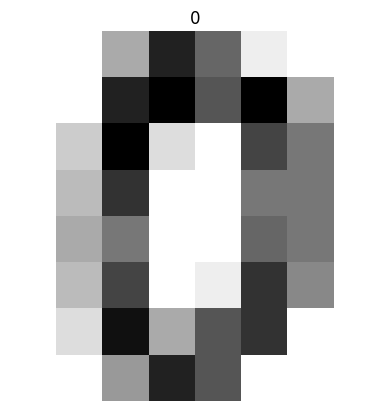

In [106]:
plt.imshow(X[0].reshape(8,8), cmap='gray_r')
plt.title(y[0])
plt.axis('off')
plt.show()

In [107]:
from sklearn.svm import SVC
model = SVC(probability=True) # probabilisy=True : 판별모형이라도 proba가능
model.fit(X,y)

SVC(probability=True)

In [110]:
# 예측값
model.predict(X[0].reshape(1,-1))

array([0])

In [112]:
# 예측확률
print(model.classes_)
print(model.predict_proba(X[0].reshape(1,-1)))

[0 1 2 3 4 5 6 7 8 9]
[[9.90941150e-01 2.06305150e-04 5.14186264e-04 8.93117322e-04
  6.20335540e-04 1.40183256e-03 7.47997521e-04 9.43716943e-04
  7.61060276e-04 2.97029858e-03]]


In [114]:
for c, p in zip(model.classes_,
                model.predict_proba(X[0].reshape(1,-1))[0]):
    print("{}일 확률 : {:.3f}".format(c,p))

0일 확률 : 0.991
1일 확률 : 0.000
2일 확률 : 0.001
3일 확률 : 0.001
4일 확률 : 0.001
5일 확률 : 0.001
6일 확률 : 0.001
7일 확률 : 0.001
8일 확률 : 0.001
9일 확률 : 0.003


In [150]:
model.score(X,y)

0.996661101836394

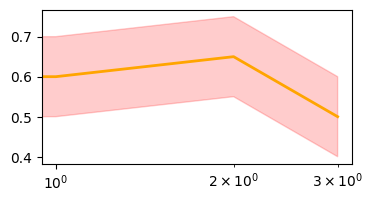

In [116]:
range = np.array([0,1,2,3])
score = np.array([0.5,0.6,0.65,0.5])
plt.figure(figsize=(4,2))
plt.semilogx(range,score,color='orange',lw=2)
plt.fill_between(range,score-0.1, score+0.1, color='red', alpha=0.2)
plt.show()

In [136]:
# SVC() 도형에서 C 파라미터 값을 다음의 범위 중 제일 좋은 C값은?
# 10의 -6승부터 10의 -1승까지 로그간격으로 균등분포 10개를 추출

param_range = np.logspace(-6, 1, 10) 
param_range

array([1.00000000e-06, 5.99484250e-06, 3.59381366e-05, 2.15443469e-04,
       1.29154967e-03, 7.74263683e-03, 4.64158883e-02, 2.78255940e-01,
       1.66810054e+00, 1.00000000e+01])

In [137]:
%%time
from sklearn.model_selection import validation_curve
train_score, test_score = validation_curve(
    SVC(),                          # 예측모형
    X,y,
    param_name='gamma',
    param_range=param_range,        #list로 파라미터 전달 / 1차원 넘파이, 시리즈
    cv=10,                          # 교차검증 : 데이터 10개중 1개씩 test 데이터로 검증하고 평균 score
    scoring ="accuracy",
    n_jobs=-1                       # 시스템의 모든 core 사용
)

CPU times: total: 469 ms
Wall time: 26.2 s


In [138]:
print(f"데이터 크기: {X.shape}")
print(f"클래스 분포: {np.bincount(y)}")
print(f"특성 범위: {X.min()}, {X.max()}")

데이터 크기: (1797, 64)
클래스 분포: [178 182 177 183 181 182 181 179 174 180]
특성 범위: 0.0, 16.0


In [139]:
train_score
# test_score

array([[0.10204082, 0.10204082, 0.10204082, 0.10204082, 0.10204082,
        0.10204082, 0.10204082, 0.28615575, 0.19159456, 0.19159456],
       [0.87631416, 0.87198516, 0.8750773 , 0.88373531, 0.87631416,
        0.87198516, 0.8707483 , 0.87082818, 0.89060569, 0.87515451],
       [0.96351268, 0.96660482, 0.9598021 , 0.96351268, 0.96289425,
        0.96165739, 0.96227582, 0.95859085, 0.96724351, 0.96600742],
       [0.99134199, 0.98886827, 0.99134199, 0.99134199, 0.98824985,
        0.99010513, 0.9894867 , 0.99011125, 0.99134734, 0.99011125],
       [0.99938157, 0.99876314, 0.99938157, 0.99876314, 0.99938157,
        0.99938157, 0.99938157, 0.99938195, 0.99938195, 0.99938195],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.       

In [125]:
train_score.shape, test_score.shape

((10, 10), (10, 10))

In [143]:
train_score_mean = np.mean(train_score, axis=1) # 행별 평균
test_score_mean = np.mean(test_score,axis=1) 
train_score_std = np.std(train_score, axis=1)
test_score_std = np.std(test_score, axis=1)

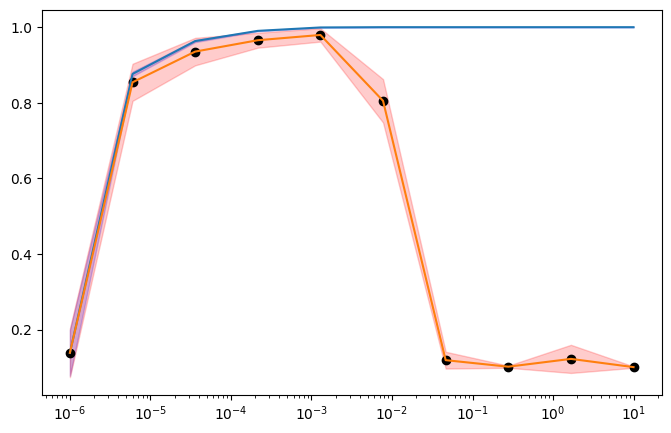

In [156]:

plt.figure(figsize=(8,5))
plt.semilogx(param_range, train_score_mean)
plt.fill_between(param_range, train_score_mean-train_score_std,
                train_score_mean+train_score_std,
                alpha=0.2,
                color='blue')
plt.semilogx(param_range, test_score_mean)
plt.fill_between(param_range, test_score_mean-test_score_std,
                test_score_mean+test_score_std,
                alpha=0.2,
                color='red')
plt.scatter(param_range, test_score_mean, c='k')

In [157]:
test_score_mean.argmax()

4

In [158]:
# 최적의 gammar 값
gamma = param_range[6]
gamma

0.04641588833612782

In [159]:
model = SVC(gamma=gamma).fit(X,y)

In [160]:
model.score(X,y)

1.0

##  2-2 GridSearchCV
- 복수개의 하이퍼 파라미터 최적화 클래스
- 모형도 가지고 옴
- fit(), score(), prediect_proba(), decision_function()

In [164]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.svm import SVC

# 데이터 
import pandas as pd
import numpy as np
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine_X ,redwine_y = redwine.iloc[:,:-1], redwine.iloc[:,-1]
redwine_X.shape, redwine_y.shape

((1599, 11), (1599,))

In [167]:
import time
start_time = time.time()
# SelectKBest로 최적의 독립변수 k개 찾음 → SVC()에서 최적의 C값을 찾음
selection = SelectKBest(k=1) # 가장 평가 점수가 높은 K개 찾음
svc = SVC(kernel='linear')   # 직선으로 나누는 가장 단순한 분류 모형
pipeline = Pipeline([('select', selection),('svc',svc)])
param_grid = dict(
                select__k = [4,5,6,7,8,9,10,11],
                svc__C = [0.1,1,10]) # 오차범위 허용 정도 (C값이 커지면 과적합이 생길 수 있음, 작은c: 허용범위 큼)

grid_search = GridSearchCV(
                        pipeline,
                        param_grid=param_grid, # 파라미터들
                        cv=2,
                        verbose=2, #로그 출력의 정도 
                        n_jobs=-1)

grid_search.fit(redwine_X.values, redwine_y.values)
end_time = time.time()
print(f"실행 시간: {end_time - start_time:.4f}초")

Fitting 2 folds for each of 24 candidates, totalling 48 fits
실행 시간: 183.8767초


In [168]:
%%time
# SelectKBest로 최적의 독립변수 k개 찾음 -> SVC()에서 최적의 C값을 찾음
selection = SelectKBest(k=1) # 가장 평가 점수가 높은 k개 찾음
svc = SVC(kernel='linear') # 직선으로 나누는 가장 단순한 분류모형
pipeline = Pipeline([('select', selection), ('svc', svc)])
param_grid = dict(select__k = [4,5,6,7,8,9,10,11],
        svc__C = [0.1, 1, 10] # 오차 범위 허용 정도(큰C:엄격, 작은C:허용범위 큼)
)
grid_search = GridSearchCV(
                pipeline,
                param_grid=param_grid, # 파라미터들
                cv=2,
                verbose=2, # 로그 출력의 수다스러운 정도
                n_jobs=-1
)
grid_search.fit(redwine_X.values, redwine_y.values)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
CPU times: total: 18.2 s
Wall time: 2min 49s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC(kernel='linear'))]),
             n_jobs=-1,
             param_grid={'select__k': [4, 5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10]},
             verbose=2)

In [169]:
# 최적의 파라미터값
grid_search.best_params_

{'select__k': 9, 'svc__C': 1}

In [172]:
# 최적의 모형
model = grid_search.best_estimator_
model.score(redwine_X.values,redwine_y.values)

0.5878674171357098

In [174]:
model = SVC().fit(redwine_X.values, redwine_y.values)
model.score(redwine_X.values, redwine_y.values)

0.5103189493433395

# 3절. 자료 불균형 처리
- 단순 언더 샘플링 
- 단, 단순 오버 샘플링시 소수의 데이터를 복사하면, 과적합 우려 
- 오버샘플링하는 방법 : SMOTE
## 3-1 SMOTE를 이용한 오버샘플링 전

In [178]:
# 데이터 
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=10000,
                          n_features=10,           # 독립변수 갯수
                          n_informative=5,         # 타겟변수에 영향을 미치는 독립변수
                          n_redundant=0,           # 
                          n_clusters_per_class=1,
                          n_classes=2,
                          weights=[0.99,0.01],
                          random_state=42
                          )
y.mean()

0.014

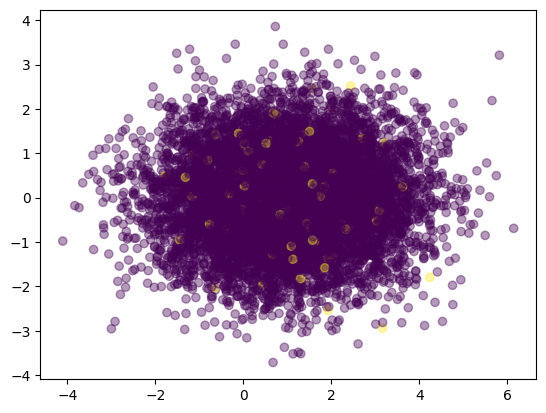

In [210]:
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.4)

In [179]:
from sklearn.model_selection import train_test_split

In [180]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7000, 10), (3000, 10), (7000,), (3000,))

In [181]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_features=2,
                                  random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [185]:
y_hat = rf_model.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(y_test,y_hat)

array([[2958,    0],
       [  34,    8]], dtype=int64)

In [187]:
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.19      0.32        42

    accuracy                           0.99      3000
   macro avg       0.99      0.60      0.66      3000
weighted avg       0.99      0.99      0.98      3000



## 3-2 SMOTE를 이용한 전체 오버샘플링 후 데이터 셋 분리 
- imbalanced-learn 라이브러리 install 

In [199]:
# 0그룹과 1그룹의 갯수
df = pd.DataFrame(np.c_[X,y])
df.iloc[:,-1].value_counts()

0.0    9860
1.0     140
Name: 10, dtype: int64

In [209]:
from imblearn.over_sampling import SMOTE
sm = SMOTE() # 0그룹 : 1그룹 = 1:1
#sm = SMOTE(sampling_strategy={0:9860, 1:420})
X_resampled, y_resample = sm.fit_resample(X,y)
X_resampled.shape,y_resample.shape

((19720, 10), (19720,))

In [207]:
# 0그룹과 1그룹의 갯수
df = pd.DataFrame(np.c_[X_resampled,y_resample])
df.iloc[:,-1].value_counts()

0.0    9860
1.0    9860
Name: 10, dtype: int64

In [212]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled,y_resample,
                                                    test_size=0.3,
                                                    stratify=y_resample,
                                                    random_state=42)

rf_model = RandomForestClassifier(n_estimators=100,
                                  max_features=2,
                                  random_state=42)

rf_model.fit(X_train, y_train)
y_hat = rf_model.predict(X_test)
confusion_matrix(y_test,y_hat)

array([[2947,   11],
       [  30, 2928]], dtype=int64)

In [213]:
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.99      0.99      2958

    accuracy                           0.99      5916
   macro avg       0.99      0.99      0.99      5916
weighted avg       0.99      0.99      0.99      5916



## 3-3 가중치 제어
- 자료 뷸균형 처리의 또 다른 방법
- sklearn의 예측 모형에서 class_weigh 매개변수 설정

In [214]:
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_features=2,
                                  class_weight={0:1,1:1.4}, # 1 그룹을 1.4배 더 중요하게 
                                  random_state=42
                                  )
rf_model.fit(X_train,y_train)

RandomForestClassifier(class_weight={0: 1, 1: 1.4}, max_features=2,
                       random_state=42)

# 4절. 앙상블 모형
- 목적 : 여러 분류모형을 하나의 메타 분류모델로 연결하여 개별 모형보다 더 좋은 일반화 성능을 달성
- 방법 : 
    * 하나의 메타 분류 알고리즘 이용 : 배깅(bagging), 부스팅(boosting) 
    * 여러 분류 알고리즘을 이용 : 다수결 투표
- 배깅 vs 부스팅 
    * 배깅
        - 복원추출로 데이터를 뽑아 병렬 학습 후 score가 높은 모델에 가중치를 부여
        - 과적합 줄일 수 있음
        - 데이터가 충분하고 과적합을 방지하면서 안정적인 모델이 필요할 때 
        - RandomForestClassifier, BagginClassifier
    * 부스팅
        - 순차적으로 모델 학습. 앞의 모델에서 틀린 데이터의 50%를 재학습
        - 오답에 가중치를 둠(오답에 더 집중)
        - 성능 극대화
        - 성능 극대화해야 하는데, 데이터가 비교적 적거나 복잡한 패턴의 학습을 해야할 경우

## 4-1 배깅 알고리즘

In [216]:
wine_df = pd.read_csv('data/wine.csv')

wine_df.sample()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
73,2,12.99,1.67,2.6,30.0,139,3.3,2.89,0.21,1.96,3.35,1.31,3.5,985


In [218]:
X = wine_df.iloc[:,1:]
y = wine_df['Class label']
X.shape, y.shape

((178, 13), (178,))

In [219]:
y.value_counts()

2    71
1    59
3    48
Name: Class label, dtype: int64

In [220]:
train_X,test_X, train_y,test_y = train_test_split(X,y,
                                                  test_size=0.3,
                                                  stratify=y,
                                                  random_state=1)

train_X.shape,test_X.shape, train_y.shape,test_y.shape

((124, 13), (54, 13), (124,), (54,))

In [222]:
# 의사결정나무 알고리즘
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree_model.fit(train_X,train_y)
tree_model.score(test_X, test_y)

0.9074074074074074

In [225]:
# 배깅 알고리즘
from sklearn.ensemble import BaggingClassifier
bag_model = BaggingClassifier(estimator=tree_model,
                              n_estimators=500,
                              bootstrap=True,           # 복원추출을 허용
                              bootstrap_features=False, # 모든 feature 사용해서 학습
                              random_state=1)
bag_model.fit(train_X,train_y)
bag_model.score(test_X,test_y)

0.9629629629629629

In [226]:
# 랜덤포레스트알고리즘
rf_model = RandomForestClassifier().fit(train_X, train_y)
rf_model.score(test_X,test_y)

1.0

### 배깅알고리즘시 0.632 규칙

In [230]:
np.random.choice(10,10,replace=True) # 10개 데이터를 10개 복원추출 뽑기

array([6, 8, 1, 3, 6, 9, 7, 8, 2, 0])

In [254]:
len(set(np.random.choice(10,10,replace=True)))

6

In [280]:
N = 10000
len(set(np.random.choice(N,N))) / N

0.6335

## 4-2임의의 데이터를 만들어

In [304]:
X,y = make_classification(n_samples=1000,
                          n_features=10,
                          n_informative=5,
                          n_redundant=0,
                          n_classes=2,
                          n_clusters_per_class=1,
                          weights=[0.9,0.1], # 0그룹:90%, 1그룹:10% 
                          random_state=42)

In [305]:
train_X,test_X,train_y,test_y = train_test_split(X,y,
                                                 test_size=0.3,
                                                 stratify=y,
                                                 random_state=42)
sm = SMOTE()
resampled_X,resampled_y = sm.fit_resample(train_X,train_y)
resampled_X.shape, resampled_y.shape, test_X.shape, test_y.shape

((1246, 10), (1246,), (300, 10), (300,))

In [295]:
from sklearn.metrics import precision_score, recall_score, f1_score
def model_measure(model, train_X=resampled_X, train_y=resampled_y,
                  test_X = test_X, test_y=test_y):
    '매개변수로 들어온 model 학습후 accuracy, precision, recall, f1score를 반환'
    model.fit(train_X, train_y)
    y_hat = model.predict(test_X) # 모델 예측값
    accuracy = model.score(test_X,test_y) 
    precision = precision_score(test_y,y_hat)
    recall = recall_score(test_y,y_hat)
    f1score = f1_score(test_y, y_hat)
    return "정확도 :{:.3f}, 정밀도:{:.3f}, 재현율:{:.3f}, f1:{:.3f}".format(accuracy,precision,recall,f1score)

In [296]:
model_measure(RandomForestClassifier(n_estimators=100,
                                    max_features=2,
                                    random_state=42))

'정확도 :0.982, 정밀도:0.938, 재현율:0.883, f1:0.910'

In [297]:
model_measure(SVC(random_state=42))

'정확도 :0.988, 정밀도:0.957, 재현율:0.929, f1:0.943'

## 4-3 부스팅 알고리즘
- Adaboost, XGB, LGBM, CatBoost

In [298]:
from sklearn.ensemble import AdaBoostClassifier
model_measure(AdaBoostClassifier())

'정확도 :0.962, 정밀도:0.761, 재현율:0.919, f1:0.833'

In [300]:
from xgboost import XGBClassifier # pip install xgboost / pip install --dray-run xgboost=1.7.3 후 설치
model_measure(XGBClassifier(max_depth=10,          # tree의 깊이
                            n_estimators=100,      # 나무 갯수
                            learning_rate = 0.01)) # 학습율


'정확도 :0.973, 정밀도:0.866, 재현율:0.877, f1:0.871'

In [303]:
from lightgbm import LGBMClassifier # pip install lightgbm
model_measure(LGBMClassifier(force_col_wise=True, verbose=0))

'정확도 :0.986, 정밀도:0.953, 재현율:0.909, f1:0.930'

## 4-4 투표를 이용한 앙상블
- voting = 'hard' : 다수결로 투표
- votting = 'soft' : 확률의 합을 계산한 투표

In [308]:
X,y = make_classification(n_samples=200,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          n_clusters_per_class=1,
                          random_state=42)

train_X,test_X,train_y,test_y = train_test_split(X,y,
                                                 test_size=0.3,
                                                 stratify=y,
                                                 random_state=42)

In [311]:
rf_model = RandomForestClassifier(max_features=2, random_state=42)
xgb_model = XGBClassifier(max_depth=10, 
                          n_estimators=100, 
                          learning_rate=0.01, # 0.01~0.2
                          eval_metric="logloss")
lgb_model = LGBMClassifier(n_estimators=100, force_col_wise=True, verbose=-1)
print(model_measure(rf_model))
print(model_measure(xgb_model))
print(model_measure(lgb_model))

정확도 :0.982, 정밀도:0.938, 재현율:0.883, f1:0.910
정확도 :0.973, 정밀도:0.866, 재현율:0.877, f1:0.871
정확도 :0.986, 정밀도:0.953, 재현율:0.909, f1:0.930


In [316]:
%%time
from sklearn.ensemble import VotingClassifier
v_model = VotingClassifier(estimators=[('rfm',rf_model),
                                       ('xgb',xgb_model),
                                       ('lgb',lgb_model)],
                          voting='hard') # soft 확률계산
# v_model.fit(train_X,train_y)
model_measure(v_model)

CPU times: total: 16 s
Wall time: 4.99 s


'정확도 :0.983, 정밀도:0.942, 재현율:0.890, f1:0.915'

In [315]:
%%time
from sklearn.ensemble import VotingClassifier
v_model = VotingClassifier(estimators=[('rfm',rf_model),
                                       ('xgb',xgb_model),
                                       ('lgb',lgb_model)],
                          voting='soft') # soft 확률계산
# v_model.fit(train_X,train_y)
model_measure(v_model)

CPU times: total: 15.9 s
Wall time: 4.85 s


'정확도 :0.983, 정밀도:0.942, 재현율:0.893, f1:0.917'